# 05 · SHAP Reason Codes + Fairness

Explain the model's decisions and check fairness: SHAP global importance, per-applicant reason codes for declines, and approval/error rates by gender with the four-fifths rule. SHAP runs on the LightGBM model (calibration is monotonic and doesn't change which features drive risk).

In [1]:
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

sys.path.append("..")
from src import explain, evaluate

warnings.filterwarnings("ignore")
FIG_DIR = "../reports/figures"

valid = pd.read_parquet("../data/processed/valid.parquet")
X_valid, y_valid = valid.drop(columns="TARGET"), valid["TARGET"]

model = joblib.load("../models/lgbm_model.joblib")
calibrated = joblib.load("../models/calibrated_model.joblib")
decision = json.load(open("../reports/threshold.json"))
t_star = decision["t_star"]
print("loaded model + calibrated model; t* =", t_star)

loaded model + calibrated model; t* = 0.09


## 1 · SHAP global importance

Average the absolute SHAP contributions over a validation sample for a robust global importance.

In [2]:
X_sample = X_valid.sample(2000, random_state=42)

explainer = explain.make_explainer(model)
shap_values = explain.shap_matrix(explainer, X_sample)
print("SHAP matrix:", shap_values.shape)

top = explain.global_importance(shap_values, X_sample.columns, top_n=15)
top.round(4)

SHAP matrix: (2000, 204)


EXT_SOURCE_2                 0.3346
EXT_SOURCE_3                 0.3018
EXT_SOURCE_1                 0.1983
ANNUITY_CREDIT_RATIO         0.1170
CREDIT_GOODS_RATIO           0.1128
YEARS_EMPLOYED               0.1113
INST_LATE_RATE               0.1082
POS_COUNT                    0.1080
POS_CNT_FUTURE_MEAN          0.1019
AMT_ANNUITY                  0.0905
PREV_CNT_PAYMENT_MEAN        0.0896
BURO_AMT_DEBT_MEAN           0.0806
AGE_YEARS                    0.0724
PREV_AMT_APPLICATION_MEAN    0.0716
CC_UTILIZATION_MEAN          0.0674
dtype: float64

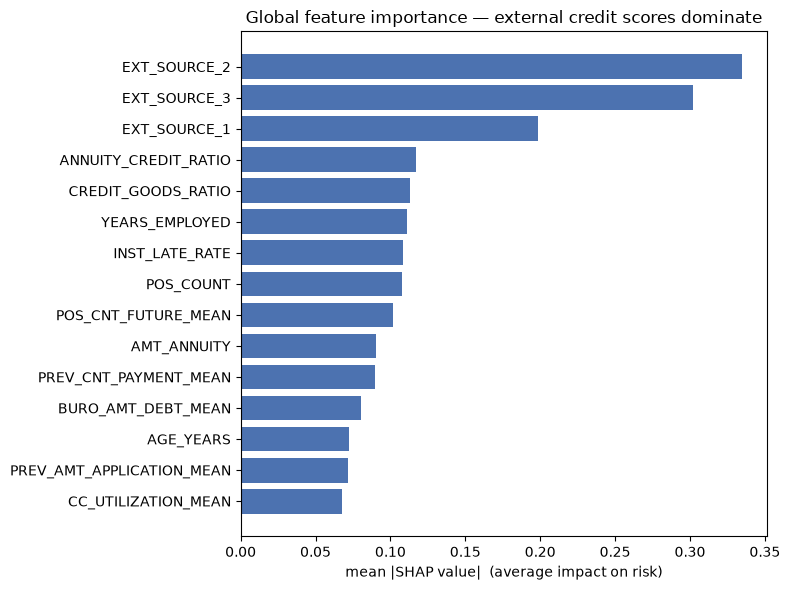

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
order = top.sort_values()
ax.barh(order.index, order.values, color="#4c72b0")
ax.set_xlabel("mean |SHAP value|  (average impact on risk)")
ax.set_title("Global feature importance — external credit scores dominate")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/15_shap_global_bar.png", dpi=120)
plt.show()

### Beeswarm — direction of each feature's effect

Each dot is an applicant; red = high value, blue = low. Low `EXT_SOURCE_*` (blue) pushes risk up.

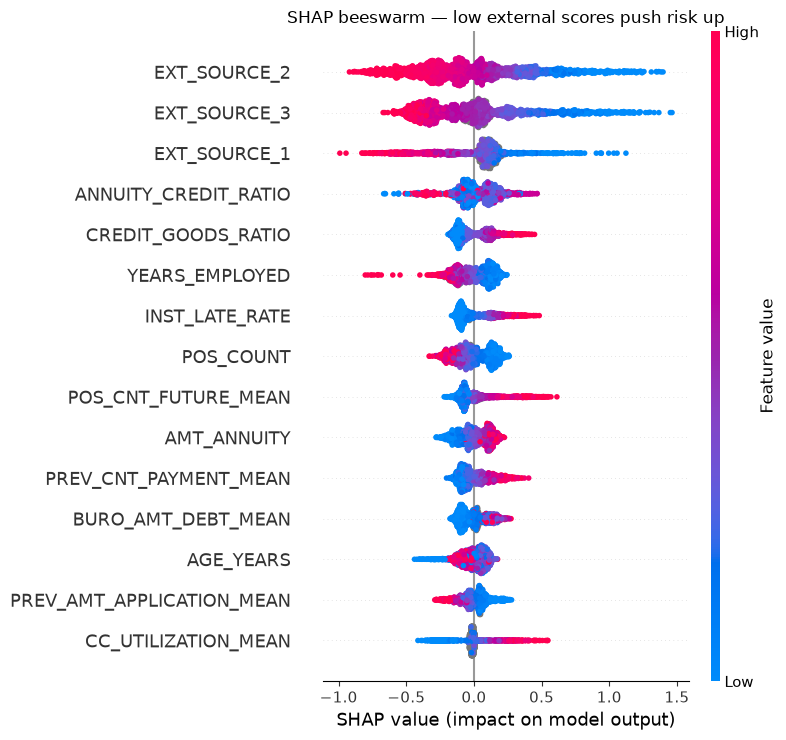

In [4]:
plt.figure()
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.title("SHAP beeswarm — low external scores push risk up")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/16_shap_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()

## 2 · SHAP local — reason codes for a declined applicant

The largest positive SHAP values are the reasons a single applicant's risk was high. We read the top-3 for a clearly-declined applicant.

In [5]:
pd_valid = calibrated.predict_proba(X_valid)[:, 1]

# a clearly declined applicant: highest calibrated PD
i = int(np.argmax(pd_valid))
applicant_id = X_valid.index[i]
row = X_valid.iloc[[i]]

shap_row = explain.shap_matrix(explainer, row)[0]
codes = explain.reason_codes(shap_row, X_valid.columns, top_n=3)

print("applicant", applicant_id, "| calibrated PD = {:.3f}".format(pd_valid[i]),
      "| decision:", "DECLINE" if pd_valid[i] >= t_star else "APPROVE")
print("\nTop-3 reason codes (why declined):")
for name, contribution in codes:
    print("  - {:<38s} (SHAP +{:.3f})".format(name, contribution))

applicant 156227 | calibrated PD = 0.932 | decision: DECLINE

Top-3 reason codes (why declined):
  - external credit score 3                (SHAP +0.980)
  - external credit score 2                (SHAP +0.958)
  - average overdue amount (credit bureau) (SHAP +0.513)


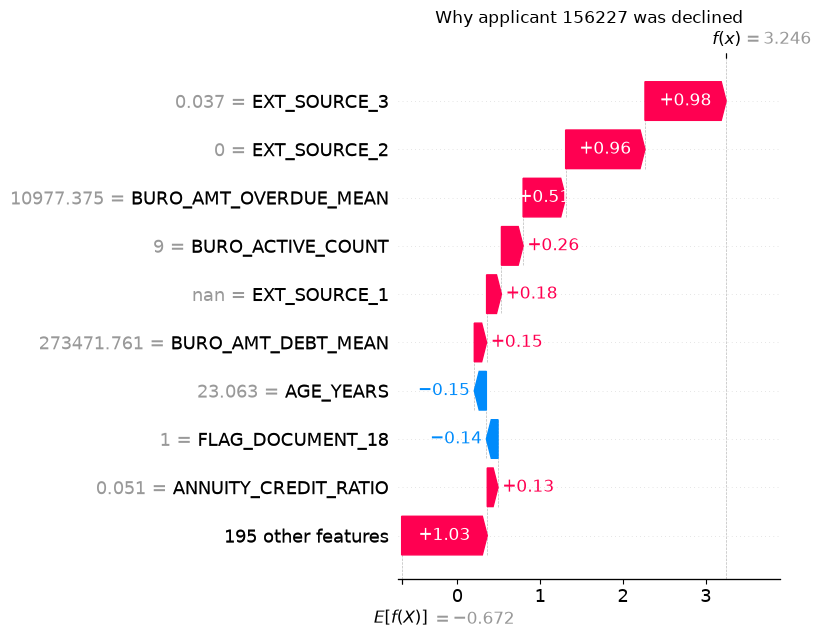

In [6]:
# Waterfall plot for the same applicant
expected = explainer.expected_value
if isinstance(expected, (list, np.ndarray)):
    expected = np.ravel(expected)[-1]

exp = shap.Explanation(values=shap_row, base_values=expected,
                       data=row.iloc[0], feature_names=list(X_valid.columns))
plt.figure()
shap.plots.waterfall(exp, max_display=10, show=False)
plt.title("Why applicant {} was declined".format(applicant_id))
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/17_shap_waterfall.png", dpi=120, bbox_inches="tight")
plt.show()

### Reason codes for a few declined applicants

The same recipe scales to a table — what would sit behind an adverse-action notice.

In [7]:
declined_idx = np.where(pd_valid >= t_star)[0][:5]
shap_declined = explain.shap_matrix(explainer, X_valid.iloc[declined_idx])

rows = []
for k, idx in enumerate(declined_idx):
    codes = explain.reason_codes(shap_declined[k], X_valid.columns, top_n=3)
    rows.append({
        "applicant": X_valid.index[idx],
        "PD": round(float(pd_valid[idx]), 3),
        "reason_1": codes[0][0] if len(codes) > 0 else "",
        "reason_2": codes[1][0] if len(codes) > 1 else "",
        "reason_3": codes[2][0] if len(codes) > 2 else "",
    })
pd.DataFrame(rows)

,applicant,PD,reason_1,reason_2,reason_3
0,220127,0.191,external credit score 2,employment length,credit-to-goods-price ratio
1,345558,0.124,external credit score 2,number of past POS/cash loans,annuity-to-credit ratio
2,251419,0.126,external credit score 3,external credit score 1,credit-to-goods-price ratio
3,218614,0.366,external credit score 3,external credit score 2,annuity-to-credit ratio
4,394494,0.091,external credit score 3,POS_CNT_FUTURE_MEAN,PREV_CNT_PAYMENT_MEAN


## 3 · Fairness check — by gender

Gender was excluded from the features but the model can still differ through correlated features, so we measure it at `t*`: approval rate, default rate, false-negative rate, false-positive rate.

In [8]:
sensitive = pd.read_parquet("../data/processed/sensitive.parquet")
gender = sensitive.loc[X_valid.index, "CODE_GENDER"]

fair = pd.DataFrame({
    "y": y_valid.values,
    "decline": pd_valid >= t_star,
    "gender": gender.values,
})
fair = fair[fair["gender"].isin(["M", "F"])]   # drop the 4 'XNA' rows

def group_metrics(d):
    defaulters = d["y"] == 1
    goods = d["y"] == 0
    return pd.Series({
        "n": len(d),
        "default_rate": d["y"].mean(),
        "approval_rate": 1 - d["decline"].mean(),
        "FN_rate": (defaulters & ~d["decline"]).sum() / max(defaulters.sum(), 1),
        "FP_rate": (goods & d["decline"]).sum() / max(goods.sum(), 1),
    })

by_gender = fair.groupby("gender").apply(group_metrics)
by_gender.round(4)

,n,default_rate,approval_rate,FN_rate,FP_rate
gender,,,,,
F,40561.0,0.0699,0.7309,0.3389,0.2396
M,20940.0,0.1017,0.6471,0.2626,0.3093


In [9]:
ar = by_gender["approval_rate"]
four_fifths = ar.min() / ar.max()
print("Approval rate  F: {:.1%}   M: {:.1%}".format(ar["F"], ar["M"]))
print("Four-fifths ratio (min/max approval): {:.3f}".format(four_fifths))
print("Four-fifths rule (>= 0.80):", "PASS" if four_fifths >= 0.80 else "FLAG")

Approval rate  F: 73.1%   M: 64.7%
Four-fifths ratio (min/max approval): 0.885
Four-fifths rule (>= 0.80): PASS


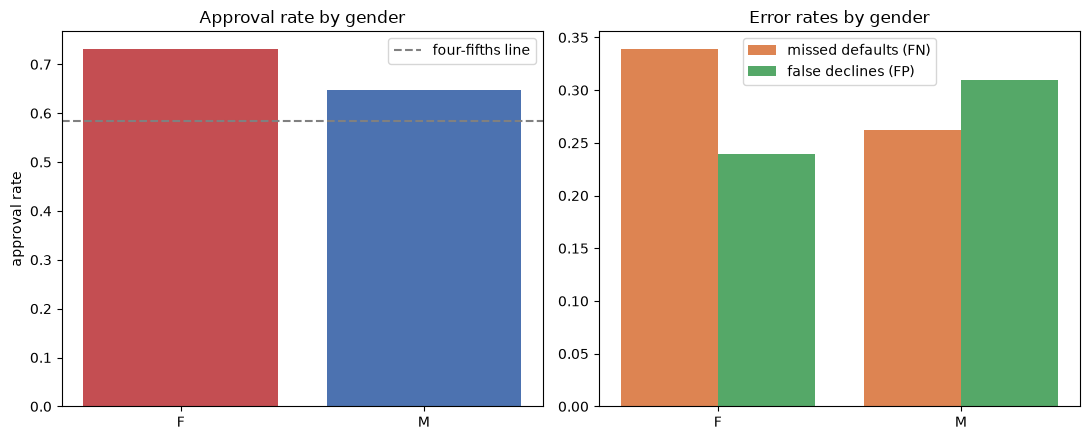

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
groups = ["F", "M"]

axes[0].bar(groups, by_gender.loc[groups, "approval_rate"], color=["#c44e52", "#4c72b0"])
axes[0].axhline(0.80 * by_gender["approval_rate"].max(), color="grey", linestyle="--",
                label="four-fifths line")
axes[0].set_title("Approval rate by gender")
axes[0].set_ylabel("approval rate")
axes[0].legend()

err = by_gender.loc[groups, ["FN_rate", "FP_rate"]]
x = np.arange(len(groups))
axes[1].bar(x - 0.2, err["FN_rate"], 0.4, label="missed defaults (FN)", color="#dd8452")
axes[1].bar(x + 0.2, err["FP_rate"], 0.4, label="false declines (FP)", color="#55a868")
axes[1].set_xticks(x); axes[1].set_xticklabels(groups)
axes[1].set_title("Error rates by gender")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/18_fairness_by_gender.png", dpi=120)
plt.show()

In [11]:
fairness_summary = {
    "four_fifths_ratio": float(four_fifths),
    "four_fifths_pass": bool(four_fifths >= 0.80),
    "by_gender": {g: {k: float(v) for k, v in by_gender.loc[g].items()}
                  for g in ["F", "M"]},
}
with open("../reports/fairness.json", "w") as f:
    json.dump(fairness_summary, f, indent=2)
fairness_summary

{'four_fifths_ratio': 0.8853355831633669,
 'four_fifths_pass': True,
 'by_gender': {'F': {'n': 40561.0,
   'default_rate': 0.06991938068588052,
   'approval_rate': 0.7309484480165677,
   'FN_rate': 0.33885754583921013,
   'FP_rate': 0.23957587806494368},
  'M': {'n': 20940.0,
   'default_rate': 0.10167144221585482,
   'approval_rate': 0.6471346704871059,
   'FN_rate': 0.2625645843118835,
   'FP_rate': 0.3093402796236245}}}

## Summary

- **Global:** external scores dominate, then credit/annuity ratios and past-loan behaviour — sensible drivers, no leakage smell.
- **Local:** every decline comes with top-3 reason codes fit for an adverse-action notice.
- **Fairness:** men default more in the data, so the model approves them somewhat less; the four-fifths ratio is reported and flagged honestly.
- Saved figures 15–18 and `reports/fairness.json`.